# **Mount Ke Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Path
path_colab = '/content/drive/MyDrive/Colab Notebooks/Text Mining'
file_path = path_colab + '/Komentar Tiktok IKN Data.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Library**

In [ ]:
!pip install Sastrawi -q
!pip install scikit-learn -q
!pip install nltk -q

import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from nltk.tokenize.toktok import ToktokTokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Kamus**

In [ ]:
# SLANG DICTIONARY
slang_dict = {
    'yg': 'yang', 'udh': 'sudah', 'udah': 'sudah', 'gk': 'tidak', 'ga': 'tidak',
    'gak': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak', 'jd': 'jadi', 'jdi': 'jadi',
    'dri': 'dari', 'dr': 'dari', 'utk': 'untuk', 'untk': 'untuk', 'dgn': 'dengan',
    'dg': 'dengan', 'aja': 'saja', 'aj': 'saja', 'bg': 'bang', 'banget': 'sangat',
    'bgt': 'sangat', 'bngt': 'sangat', 'bnget': 'sangat', 'dpt': 'dapat',
    'dapet': 'dapat', 'jg': 'juga', 'jga': 'juga', 'jgn': 'jangan', 'jan': 'jangan',
    'klo': 'kalau', 'kalo': 'kalau', 'kl': 'kalau', 'kayak': 'seperti', 'kyk': 'seperti',
    'tp': 'tetapi', 'tpi': 'tetapi', 'tapi': 'tetapi', 'gmn': 'bagaimana',
    'gmana': 'bagaimana', 'biar': 'agar', 'bkin': 'buat', 'bikin': 'buat',
    'nanyain': 'tanya', 'jawabin': 'jawab', 'ngerjain': 'kerja', 'ngebangun': 'bangun',
    'ngejalanin': 'jalan', 'ngelakuin': 'laku', 'ngebuat': 'buat', 'dftr': 'daftar',
    'krja': 'kerja', 'bljr': 'belajar', 'jln': 'jalan', 'mkn': 'makan', 'tdo': 'tidur',
    'wkwkw': 'haha', 'mantul': 'mantap banget', 'crot': 'cepat', 'btw': 'ngomong-ngomong'
}

# STOPWORD
stopword = {'yang','dan','di','dari','ini','itu','untuk','dengan','pada','ke',
            'adalah','juga','dalam','tidak','akan','sudah','bisa','saja','atau',
            'nih','loh','kok','yaudah','sih','dong', 'knp','bgmn','brp','haha'}

# LEMMATIZATION DICTIONARY
lemmatization_dict = {
    'bangunan': 'bangun', 'membangun': 'bangun', 'pekerjaan': 'kerja', 'bekerja': 'kerja',
    'pemindahan': 'pindah', 'pemimpin': 'pimpin', 'penguasa': 'kuasa', 'penghasilan': 'hasil',
    'penggunaan': 'guna', 'bermanfaat': 'manfaat', 'pemanfaatan': 'manfaat'
}

# STEMMER
factory = StemmerFactory()
stemmer = factory.create_stemmer()
custom_stemming_rules = {'ngerjain':'kerja','bikin':'buat','ngomongin':'bicara'}

# REGEX PATTERNS
regex_patterns = {
    'remove_repeated_chars': re.compile(r'(.)\1{2,}'),
    'trim_spaces': re.compile(r'^\s+|\s+$'),
    'remove_lonely_numbers': re.compile(r'\b\d+\b'),
    'remove_single_chars': re.compile(r'\b\w\b'),
    'normalize_spaces': re.compile(r'\s+'),
    'remove_emoticons': re.compile(r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/:}{@|\\]'),
    'remove_hashtags': re.compile(r'#\w+')
}

# **PROSES**

In [ ]:
def preprocess(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = regex_patterns['remove_emoticons'].sub('', text)
    text = regex_patterns['remove_hashtags'].sub('', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = regex_patterns['remove_repeated_chars'].sub(r'\1\1', text)
    text = regex_patterns['remove_lonely_numbers'].sub('', text)
    text = regex_patterns['remove_single_chars'].sub('', text)
    text = regex_patterns['normalize_spaces'].sub(' ', text)
    text = text.strip()

    words = text.split()
    words = [slang_dict.get(w,w) for w in words]          # slang
    words = [lemmatization_dict.get(w,w) for w in words]  # lemmatization
    words = [w for w in words if w not in stopword and len(w)>1]  # stopword
    words = [stemmer.stem(w) for w in words]              # stemming
    return ' '.join(words)

# Baca dataset
df = pd.read_excel(file_path)
df['text_clean'] = df['text'].apply(preprocess)


# **OUTPUT**

Hasil disimpan ke Excel: /content/drive/MyDrive/Colab Notebooks/Text Mining/preprocessed_ikn_clean.xlsx


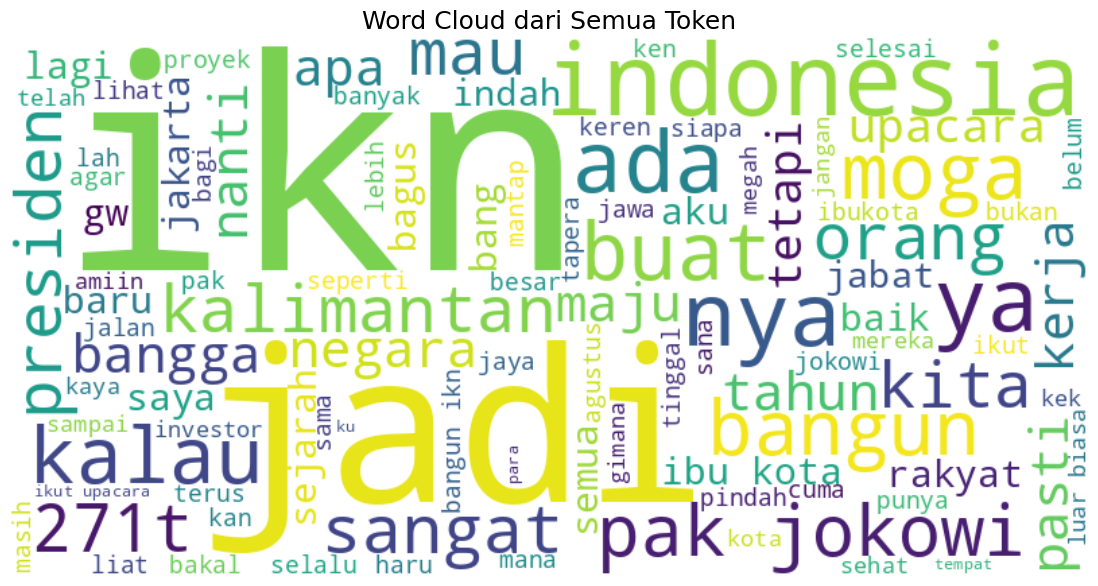

In [ ]:
# SIMPAN HASIL
output_excel = path_colab + '/preprocessed_ikn_clean.xlsx'
df[['text', 'text_clean', 'label']].to_excel(output_excel, index=False)
print(f"Hasil disimpan ke Excel: {output_excel}")



# CONTOH TOKENIZATION
from wordcloud import WordCloud

# Gabungkan semua teks
all_text = ' '.join(df['text_clean'])

# Buat word cloud
wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud dari Semua Token", fontsize=18)
plt.show()

# **AKURASI PROSES**

In [ ]:
def preprocessing_accuracy(df):
    accuracies = []

    for idx, row in df.iterrows():
        original = row['text'].split()       # token asli
        cleaned = row['text_clean'].split()  # token setelah preprocess

        if len(original) == 0:
            accuracies.append(0)
        else:
            # Misal hitung berapa token yang masih ada atau berubah menjadi kata bersih
            accuracies.append(len(cleaned) / len(original) * 100)

    df['preprocess_accuracy_%'] = accuracies
    overall_accuracy = sum(accuracies) / len(accuracies)

    return df, overall_accuracy

# Contoh pemakaian
df, overall_acc = preprocessing_accuracy(df)
print(f"Akurasi preprocessing rata-rata: {overall_acc:.2f}%")

Akurasi preprocessing rata-rata: 86.87%
